# 08-Object Detection Metrics

In our previous lessons, we mastered Image Classification. We built deep Convolutional Neural Networks (CNNs) that look at a matrix of pixels and output a single probability: *"There is an 85% chance this entire image is a space shuttle."*

But Image Classification is fundamentally blind to geometry. If there are 3 astronauts, 2 flags, and a space shuttle in the image, a standard classification network will fail catastrophically. To solve real-world problems—like autonomous driving or robotic surgery—we must transition from Image Classification to **Object Detection**. We must teach the network to output not just *what* the object is, but exactly *where* it is.

Before we can architect an Object Detection network, we must define the mathematical rulers used to measure geometric failure.

Let's set up our PyTorch environment and load our test subject.

In [1]:
import torch
from skimage import data
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Object Detection Metrics Environment Ready.")

✅ PyTorch Object Detection Metrics Environment Ready.


# 1. The Mathematics of Bounding Boxes

In Object Detection, the network does not just output a Class ID (e.g., `Class 1: Astronaut`). It must simultaneously output a set of four continuous numbers representing a geometric rectangle called a **Bounding Box**.

There are two major Cartesian coordinate systems used in the industry:

### 1. The Absolute Format (Pascal VOC Standard)

The box is defined by its top-left and bottom-right pixel coordinates.

* **Vector**: $[x_{min}, y_{min}, x_{max}, y_{max}]$
* **Pros**: Mathematically simple for calculating intersections and plotting on a standard matrix where the origin $(0,0)$ is the top-left corner.

### 2. The Center Format (YOLO Standard)

The box is defined by its exact center point, its total width, and its total height.

* **Vector**: $[x_c, y_c, w, h]$
* **Pros**: Neural networks are much better at predicting the physical center of mass of an object and scaling a box around it, rather than independently guessing two disconnected corners.

*(Engineering Note: During training, you must constantly mathematically translate your predictions between these two formats depending on the specific Loss Function or Metric you are calculating!)*

# 2. Intersection over Union (IoU)

If our network predicts a bounding box, how do we know if it is correct? In standard regression, we use Mean Squared Error (MSE). But MSE is terrible for bounding boxes. If a predicted box is 10 pixels too wide, is that a big error? If the object is a massive truck, 10 pixels is nothing. If the object is a distant stoplight, 10 pixels means you completely missed it.

We need a metric that measures **scale-invariant geometric overlap**. We use **Intersection over Union (IoU)**, mathematically known as the Jaccard Index.

$$IoU = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$

1. **Intersection (The Overlap)**: Calculate the exact square pixel area where the predicted box and the ground truth box physically overlap.
2. **Union**: Calculate the total square pixel area covered by *both* boxes combined.
3. **The Ratio**: Divide the Intersection by the Union.

* **$IoU = 1.0$**: A mathematically flawless, pixel-perfect match.
* **$IoU = 0.0$**: The boxes do not touch at all.
* **The Industry Standard**: An IoU greater than **$0.50$** is generally considered a "True Positive" (a successful detection).

# 3. Non-Maximum Suppression (NMS)

Object Detection networks do not naturally output just one box per object. Due to the sliding window nature of CNNs, the network will look at Eileen Collins's face and confidently generate 50 slightly overlapping bounding boxes for that exact same face.

We must algorithmically clean up this noise before rendering the output. We use **Non-Maximum Suppression (NMS)**.

**The NMS Algorithm:**

1. Look at all predicted boxes for a specific class (e.g., Face).
2. Discard any box with a confidence score below a base threshold (e.g., $< 0.25$).
3. Sort the remaining boxes by their confidence score from highest to lowest.
4. **The Anchor**: Take the absolute highest confidence box (e.g., $99\%$) and declare it a "Final Output".
5. **The Suppression**: Calculate the IoU between this Anchor box and all other remaining boxes. If any other box has an IoU $> 0.45$ with the Anchor, it is looking at the same face. **Delete it.**
6. Repeat Step 4 for the next highest surviving box until all boxes are evaluated.

# 4. Implementing IoU and NMS on a Real Image

Let's build the fundamental mathematical engines of Object Detection from scratch. We will write a vectorized IoU calculator, simulate a messy network output, and run the NMS algorithm to clean it up, visualizing the mathematical reality on the actual photograph.

--- 🚨 Simulating Raw Neural Network Output ---
--- 🧹 Executing Non-Maximum Suppression (IoU Threshold=0.45) ---
Surviving Box Indices: [0, 5]


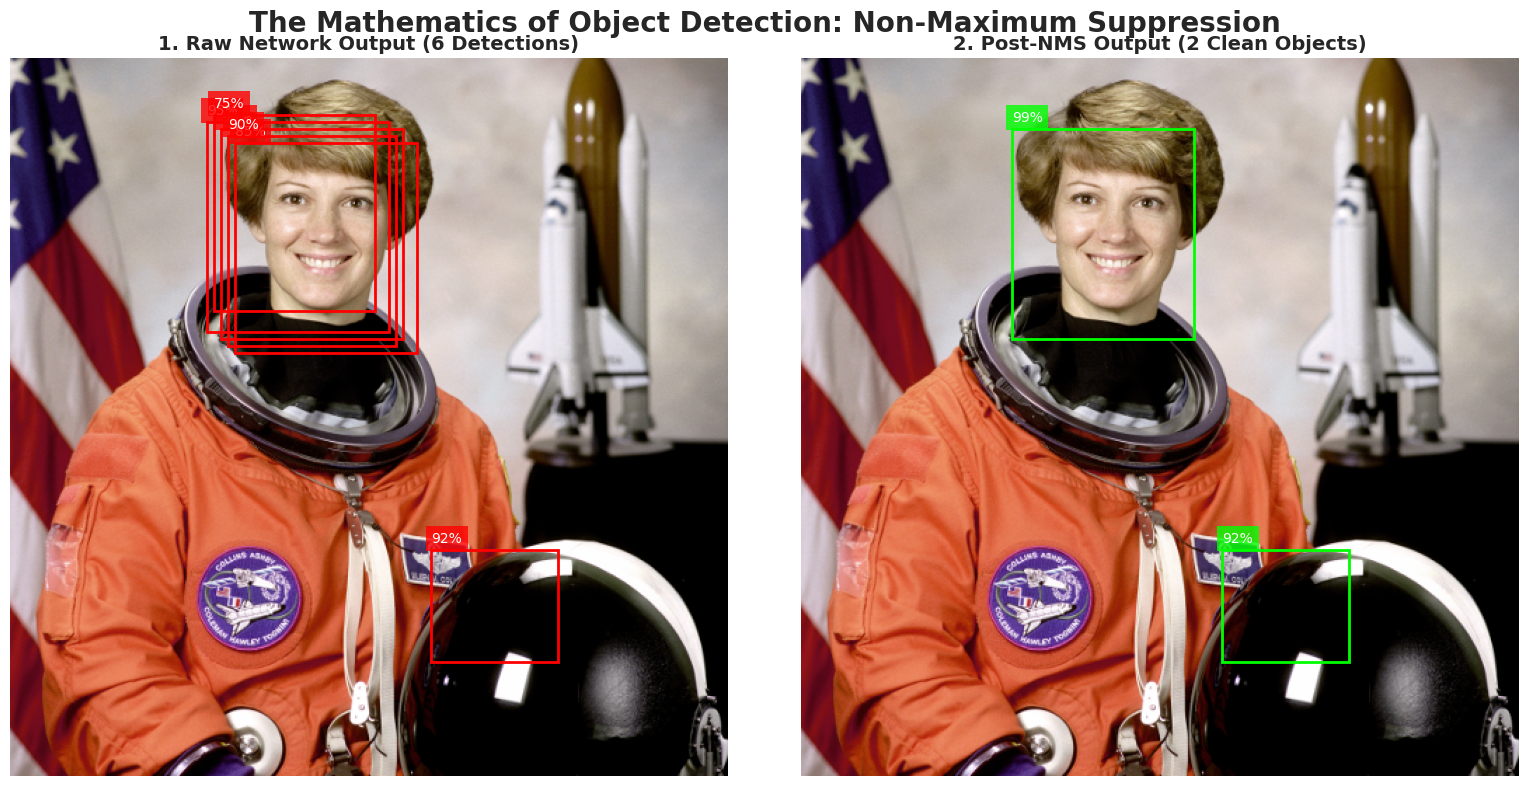

--- 💡 Engineering Insight ---
Look at the raw output on the left. A Convolutional Neural Network fires multiple times as its kernel slides over the astronaut's face, creating a cloud of geometric noise. By passing these coordinates through the NMS algorithm, we mathematically calculate the Intersection over Union (IoU) of every box against the 99% Anchor. Because boxes 1, 2, 3, and 4 heavily overlapped the anchor, they were ruthlessly deleted. Because box 5 (the NASA logo) had an IoU of exactly 0.0 with the face, it perfectly survived the suppression.


In [2]:
# 1. Fetch the Target Image
img = data.astronaut()

# 2. Vectorized Intersection over Union (IoU)
def calculate_iou(boxA, boxB):
    """
    Calculates the IoU between two bounding boxes.
    Boxes are expected in [x_min, y_min, x_max, y_max] format.
    """
    # 1. Determine the coordinates of the intersection rectangle
    x_left = torch.max(boxA[0], boxB[0])
    y_top = torch.max(boxA[1], boxB[1])
    x_right = torch.min(boxA[2], boxB[2])
    y_bottom = torch.min(boxA[3], boxB[3])

    # 2. Calculate Intersection Area
    # We use torch.clamp to ensure we don't get negative areas if boxes don't overlap!
    intersection_area = torch.clamp(x_right - x_left, min=0) * torch.clamp(y_bottom - y_top, min=0)

    # 3. Calculate Union Area
    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union_area = boxA_area + boxB_area - intersection_area

    # 4. Calculate Ratio (Add a microscopic epsilon to prevent division by zero)
    iou = intersection_area / (union_area + 1e-6)
    return iou

# 3. The Non-Maximum Suppression (NMS) Algorithm
def nms(boxes, scores, iou_threshold=0.45):
    """
    Filters overlapping bounding boxes using NMS.
    """
    # Sort boxes by confidence score (Highest to Lowest)
    sorted_indices = torch.argsort(scores, descending=True)
    keep_boxes = []

    while len(sorted_indices) > 0:
        # Step A: Take the box with the highest score (The Anchor)
        current_index = sorted_indices[0]
        keep_boxes.append(current_index.item())

        # If it's the last box, we are done
        if len(sorted_indices) == 1:
            break

        # Step B: Calculate IoU of the current Anchor with all remaining boxes
        current_box = boxes[current_index]
        remaining_indices = sorted_indices[1:]
        ious = torch.tensor([calculate_iou(current_box, boxes[idx]) for idx in remaining_indices])

        # Step C: Keep ONLY the boxes whose IoU is BELOW the threshold
        # (Meaning they do not significantly overlap with our Anchor)
        filtered_indices = remaining_indices[ious <= iou_threshold]
        
        # Update our list of boxes to process
        sorted_indices = filtered_indices

    return keep_boxes

# 4. Simulation: A Messy Network Output
print("--- 🚨 Simulating Raw Neural Network Output ---")

# Format: [x_min, y_min, x_max, y_max]
# We simulate 5 boxes clustering around the face, and 1 separate box on the NASA logo
predicted_boxes = torch.tensor([
    [150, 50,  280, 200], # Box 0: Face (99% Conf) - THE ANCHOR
    [140, 45,  270, 195], # Box 1: Face (95% Conf) - Massive overlap
    [160, 60,  290, 210], # Box 2: Face (85% Conf) - Massive overlap
    [155, 55,  275, 205], # Box 3: Face (90% Conf) - Massive overlap
    [145, 40,  260, 180], # Box 4: Face (75% Conf) - High overlap
    [300, 350, 390, 430], # Box 5: NASA Logo (92% Conf) - Completely separate object!
], dtype=torch.float32)

confidence_scores = torch.tensor([0.99, 0.95, 0.85, 0.90, 0.75, 0.92])

# 5. Execute NMS Cleanup
print("--- 🧹 Executing Non-Maximum Suppression (IoU Threshold=0.45) ---")
surviving_indices = nms(predicted_boxes, confidence_scores, iou_threshold=0.45)
print(f"Surviving Box Indices: {surviving_indices}")

# 6. Visualizing the Mathematical Cleanup
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("The Mathematics of Object Detection: Non-Maximum Suppression", fontsize=20, fontweight='bold')

def draw_boxes(ax, image, boxes, scores, indices, title, color):
    ax.imshow(image)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.axis('off')
    for idx in indices:
        box = boxes[idx].numpy()
        score = scores[idx].item()
        # width = x_max - x_min, height = y_max - y_min
        rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1], 
                                 linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(box[0], box[1] - 5, f"{score*100:.0f}%", color='white', fontsize=10, 
                bbox=dict(facecolor=color, alpha=0.8, edgecolor='none'))

# Plot A: Messy Raw Output
all_indices = list(range(len(predicted_boxes)))
draw_boxes(axes[0], img, predicted_boxes, confidence_scores, all_indices, "1. Raw Network Output (6 Detections)", 'red')

# Plot B: Cleaned Output
draw_boxes(axes[1], img, predicted_boxes, confidence_scores, surviving_indices, "2. Post-NMS Output (2 Clean Objects)", 'lime')

plt.tight_layout()
plt.show()

print("--- 💡 Engineering Insight ---")
print("Look at the raw output on the left. A Convolutional Neural Network fires multiple times as its kernel slides over the astronaut's face, creating a cloud of geometric noise. By passing these coordinates through the NMS algorithm, we mathematically calculate the Intersection over Union (IoU) of every box against the 99% Anchor. Because boxes 1, 2, 3, and 4 heavily overlapped the anchor, they were ruthlessly deleted. Because box 5 (the NASA logo) had an IoU of exactly 0.0 with the face, it perfectly survived the suppression.")

## Real-World Use Case or Analogy:

Think of Object Detection Metrics like **Finding a lost child at a crowded carnival**:

* **Image Classification**: Someone hands you a photo of the carnival and asks, *"Is the child in this photo?"* You say, *"Yes, 99% probability."* Helpful, but you still don't know *where* to look.
* **Intersection over Union (IoU)**: You draw a red circle on the map where you think the child is. The security guards draw a blue circle where the child *actually* is. If your red circle covers the exact same area as their blue circle, your IoU is 1.0. If you circled the Ferris Wheel, and the child is at the Hot Dog stand, your IoU is 0.0.
* **Non-Maximum Suppression (NMS)**: You have 10 security guards looking for the child. Suddenly, 6 guards all jump on their radios at the exact same time screaming, *"I FOUND HIM NEAR THE FERRIS WHEEL!"* You don't have 6 children. You have 1 child and 6 noisy guards. You look at the guard with the highest-powered binoculars (Confidence Score = 99%), trust their exact coordinates (The Anchor), and tell the other 5 guards looking at that exact same geometric area to turn off their radios (Suppression).